# Качество 3D-моделей: от анализа данных до submission

Для каждого объекта определяем десять дефектов и метку качества. Сначала разбираем разметку и изображения, затем сравниваем визуальный baseline, геометрическую модель и ансамбль на локальных признаках DINOv2. В notebook оставлены обучение, калибровка и анализ ошибок. Конфигурации и число эпох взяты из завершённых экспериментов.

Финальный `patch_only336` с тремя seed получил **14.22150244576055 из 20** на платформе. Он воспроизводит `submission_patch_only336_three_seeds_51b5edf5f6.csv`. Конкурсный результат относится только к этому ансамблю.

Полная история поиска сохранена рядом: [baseline и геометрия](research_baseline_and_geometry.ipynb), [эксперименты с patch-признаками](research_patch_experiments.ipynb).

## 1. Среда и параметры запуска

По умолчанию `RUN_TRAINING=False`: используем сохранённые веса и журналы, пересчитываем аналитику и создаём тестовый CSV. При `True` последовательно обучаем все три ветви с фиксированными параметрами, заново получаем validation-предсказания и пороги. Новые веса и результаты сохраняются в отдельный каталог запуска.

Локально выберите ядро `.venv`. Для Colab распакуйте проект и `final_assets.zip` в рабочую папку, подключите данные. Переменная `MESH_DATA_ROOT` задаёт папку с `train.csv`, `test.csv`, `train/`, `test/`. Прямые ссылки на ZIP можно передать через `MESH_DATA_URL` и `MESH_ASSETS_URL`, в том числе через Colab Secrets. Конкурсные данные закрыты, поэтому публичной ссылки на них в проекте нет.

In [1]:
from pathlib import Path
import importlib.util
import importlib.metadata
import os
import subprocess
import sys

ROOT = Path.cwd()
if not (ROOT / 'configs/final.json').exists():
    raise FileNotFoundError('Запустите notebook из корня распакованного проекта.')

modules = ['torch', 'torchvision', 'timm', 'numpy', 'pandas', 'sklearn', 'PIL', 'matplotlib', 'tqdm']
if any(importlib.util.find_spec(name) is None for name in modules):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(ROOT / 'requirements.txt')])

if importlib.metadata.version('timm') != '1.0.29':
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'timm==1.0.29'])

# Colab Secrets are optional; local files work without them.
if 'google.colab' in sys.modules or 'COLAB_RELEASE_TAG' in os.environ:
    from google.colab import userdata
    for name in ['MESH_ASSETS_URL', 'MESH_DATA_URL', 'MESH_DATA_ROOT']:
        if not os.environ.get(name):
            try:
                value = userdata.get(name)
                if value:
                    os.environ[name] = value
            except (userdata.SecretNotFoundError, userdata.NotebookAccessError):
                pass

sys.path.insert(0, str(ROOT / 'src'))
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from mesh_quality.pipeline import load_project, get_device, feature_store, predict_ensemble, save_submission, sha256
from mesh_quality.metrics import scores, tune_thresholds
from mesh_quality.training import seed_everything
from mesh_quality.reporting import explain_object

CONFIG, ASSETS, DATA = load_project(ROOT)
DEVICE = get_device()
torch.set_num_threads(min(8, os.cpu_count() or 1))
RUN_TRAINING = False
RUN_EXPLANATIONS = True
OUTPUT = ROOT / 'outputs/final'
OUTPUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

print(f'''Устройство: {DEVICE}
Модель: {CONFIG['model_name']}
Разрешение: {CONFIG['resolution']} × {CONFIG['resolution']}
Seed ансамбля: {CONFIG['seeds']}
Обучение: {'включено' if RUN_TRAINING else 'выключено; используются сохранённые веса'}
''')
from datetime import datetime
from time import perf_counter
from contextlib import nullcontext
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
import timm
from sklearn.metrics import average_precision_score, precision_recall_fscore_support, confusion_matrix
from mesh_quality.data import PatchDataset, image_views, load_backbone
from mesh_quality.comparisons import GlobalDataset, SurfaceDataset, global_features
from mesh_quality.geometry import chunked_knn, sample_mesh_surface

COMPARISONS = json.loads((ROOT / 'configs/comparisons.json').read_text())
RUN_DIR = OUTPUT / ('training_' + datetime.now().strftime('%Y%m%d_%H%M%S'))
ACTIVE_ASSETS = ASSETS
ACTIVE_CONFIG = dict(CONFIG)
seed_everything(42)

Устройство: mps
Модель: vit_small_patch14_dinov2.lvd142m
Разрешение: 336 × 336
Seed ансамбля: [42, 17, 123]
Обучение: выключено; используются сохранённые веса



## 2. Разметка и состав данных

Идентификатор связывает PNG, NPZ и строку таблицы; читаем его как строку. У объекта может быть несколько дефектов. В предсказаниях `quality=1`, только если все десять меток равны нулю. Сравниваем это правило с исходной разметкой перед обучением.

In [2]:
labels = pd.read_csv(
    DATA / 'train.csv',
    dtype={'item_id': str}
).set_index('item_id')

test_ids = pd.read_csv(
    DATA / 'test.csv',
    dtype={'item_id': str}
).item_id.tolist()

splits = pd.read_csv(
    ROOT / 'configs/splits.csv',
    dtype={'item_id': str}
)

inner_split = pd.read_csv(
    ROOT / 'configs/inner_split.csv',
    dtype={'item_id': str}
)

defects = CONFIG['defect_columns']
target_columns = defects + ['quality']

label_summary = pd.DataFrame(
    {
        'count': labels[defects].sum(),
        'share': labels[defects].mean()
    }
)

display(label_summary.sort_values('count', ascending=False).round(4))

quality_from_labels = (labels[defects].sum(axis=1) == 0).astype(int)

print(f'''Размеченных объектов: {len(labels)}
Тестовых объектов: {len(test_ids)}
Хороших объектов: {int(labels.quality.sum())}
Несовпадений quality с правилом отсутствия дефектов: {int((labels.quality != quality_from_labels).sum())}
''')

,count,share
noisy,2549,0.2844
simple,1929,0.2152
abstract,1194,0.1332
lowpoly,1107,0.1235
set,936,0.1044
open,544,0.0607
artifacts,435,0.0485
partial,376,0.0419
intersection,107,0.0119
scale,107,0.0119


Размеченных объектов: 8964
Тестовых объектов: 669
Хороших объектов: 1372
Несовпадений quality с правилом отсутствия дефектов: 0



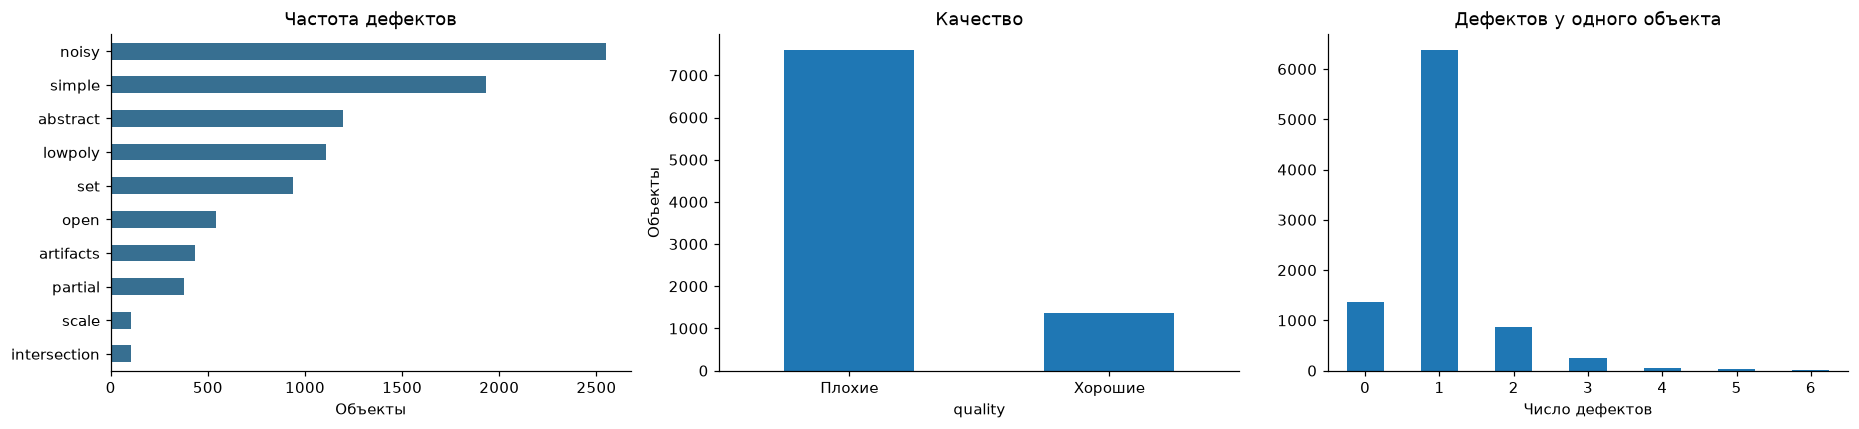

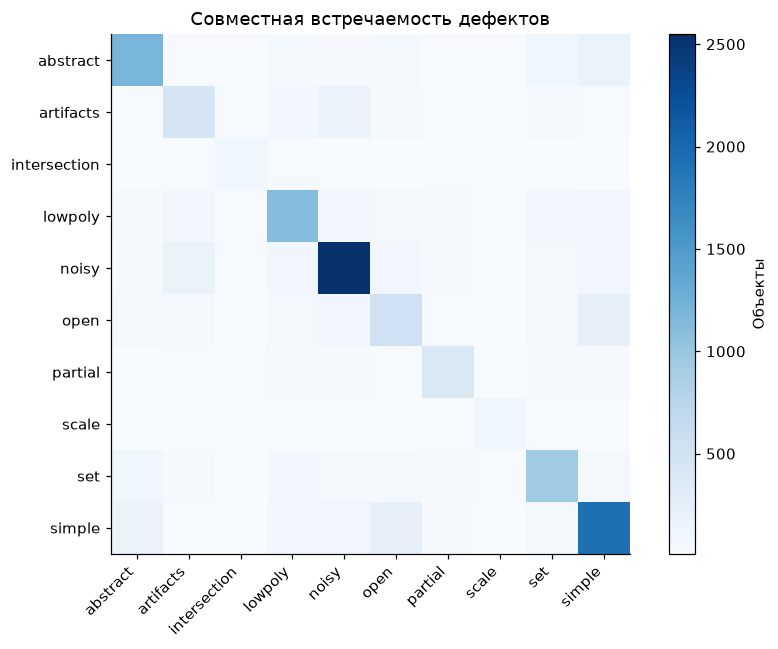

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

label_summary['count'].sort_values().plot.barh(ax=axes[0], color='#376f91')

axes[0].set(
    title='Частота дефектов',
    xlabel='Объекты'
)

labels.quality.value_counts().sort_index().rename(
    index={
        0:'Плохие',
        1:'Хорошие'
        }
).plot.bar(ax=axes[1], rot=0)

axes[1].set(title='Качество', ylabel='Объекты')
labels[defects].sum(axis=1).value_counts().sort_index().plot.bar(ax=axes[2], rot=0)
axes[2].set(title='Дефектов у одного объекта', xlabel='Число дефектов')
plt.tight_layout()
plt.show()

cooccurrence = labels[defects].astype(int).T @ labels[defects].astype(int)
fig, ax = plt.subplots(figsize=(8, 6))
heat = ax.imshow(cooccurrence, cmap='Blues')
ax.set(
    xticks=range(10),
    yticks=range(10),
    xticklabels=defects,
    yticklabels=defects,
    title='Совместная встречаемость дефектов'
)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
fig.colorbar(heat, ax=ax, label='Объекты')
plt.tight_layout()
plt.show()

Редкие классы представлены значительно слабее частых. Поэтому вместе с общей метрикой показываем поддержку каждого класса, precision и recall. Матрица совместной встречаемости объясняет, почему нельзя рассматривать `quality` как независимую метку.

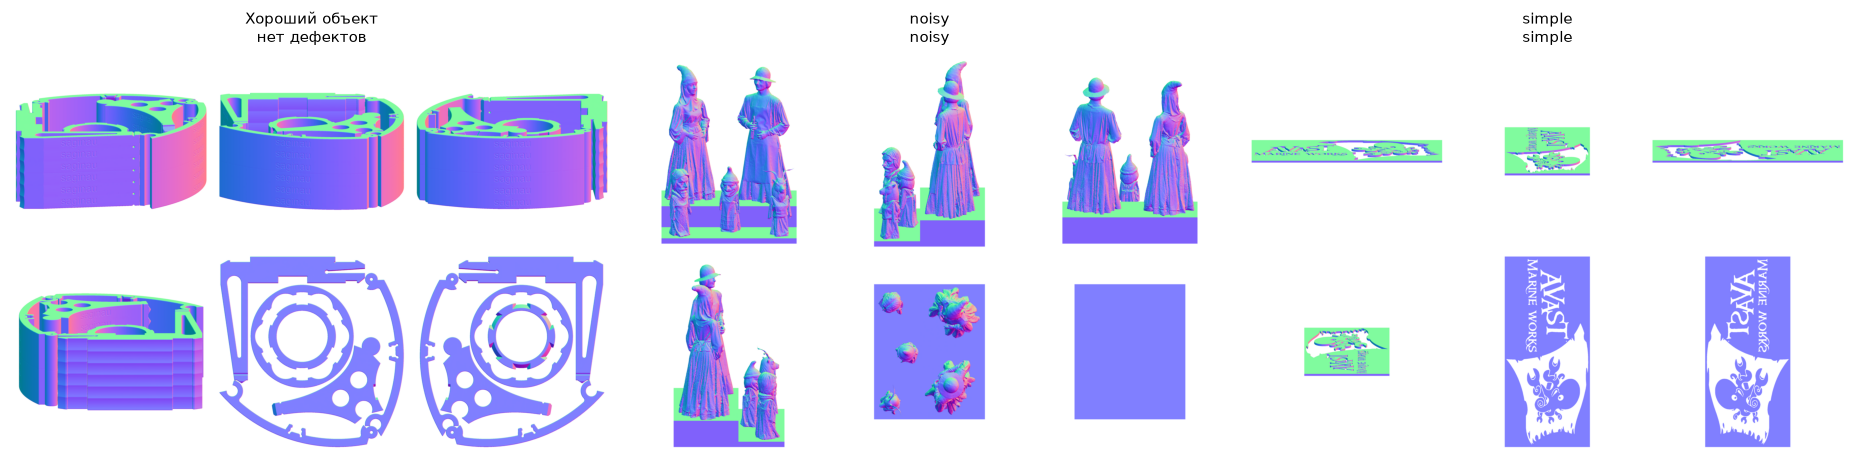

In [4]:
example_masks = {
    'Хороший объект': labels.quality.eq(1),
    'noisy': labels.noisy.eq(1),
    'simple': labels.simple.eq(1)
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (title, mask) in zip(axes, example_masks.items()):
    item = labels.index[mask][0]
    with Image.open(
        DATA / 'train' / f'{item}.png'
    ) as image:
        ax.imshow(image)
    present = ', '.join(name for name in defects if labels.loc[item, name] == 1) or 'нет дефектов'
    ax.set_title(f'{title}\n{present}', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Фиксированное разбиение

Train содержит 5970 объектов. Внутри него 4775/1195 использовались для выбора конфигураций и числа эпох по weighted AP. Внешние 2994 разделены на calibration и check: пороги подбираются на calibration, результаты сравниваются на check. Группы точных дубликатов изображений сохранены в `configs/splits.csv`.

Check уже просматривалась в ходе исследований, поэтому её результат не является полностью независимой финальной оценкой. Сейчас разбиение не меняем и параметры по check не подбираем.

In [5]:
train_ids = splits.loc[splits.split.eq('train'), 'item_id'].tolist()
valid_ids = splits.loc[splits.split.ne('train'), 'item_id'].tolist()
inner_train_ids = inner_split.loc[inner_split.part.eq('train'), 'item_id'].tolist()
inner_valid_ids = inner_split.loc[inner_split.part.eq('valid'), 'item_id'].tolist()
calibration_ids = set(splits.loc[splits.split.eq('calibration'), 'item_id'])
calibration = np.array([item in calibration_ids for item in valid_ids])
check = ~calibration
train_y = labels.loc[train_ids, target_columns].to_numpy(dtype=np.float32)
valid_y = labels.loc[valid_ids, target_columns].to_numpy(dtype=np.float32)

display(splits.groupby('split', sort=False).size().rename('objects').to_frame())

balance = pd.DataFrame(
    {part: labels.loc[frame.item_id, defects].mean() for part, frame in splits.groupby('split')}
)

display(balance.round(4))

print(f'''Групп дубликатов, пересекающих части: {int((splits.groupby('group_id').split.nunique() > 1).sum())}
Внутреннее обучение: {len(inner_train_ids)}
Внутренняя валидация: {len(inner_valid_ids)}
''')

,objects
split,
train,5970
calibration,1496
check,1498


,calibration,check,train
abstract,0.1330,0.1328,0.1333
artifacts,0.0488,0.0481,0.0486
intersection,0.0114,0.0120,0.0121
lowpoly,0.1230,0.1235,0.1236
noisy,0.2841,0.2830,0.2848
open,0.0602,0.0607,0.0608
partial,0.0421,0.0414,0.0420
scale,0.0120,0.0113,0.0121
set,0.1043,0.1041,0.1045
simple,0.2146,0.2150,0.2154


Групп дубликатов, пересекающих части: 0
Внутреннее обучение: 4775
Внутренняя валидация: 1195



## 4. Изображения и признаки DINOv2

Коллаж состоит из сетки 3×2. Каждый квадрат становится отдельным видом. Для baseline используем разрешение 224 и CLS-вектор длины 384. Для финальной модели разрешение 336 даёт 576 patch-токенов на вид. Encoder заморожен, поэтому признаки можно один раз сохранить и повторно использовать при обучении голов.

Ниже показан код обработки изображений. Дисковый кэш и загрузка весов находятся в `src/mesh_quality/data.py`.

In [6]:
from torchvision import transforms

def image_views(path, config):
    with Image.open(path) as image:
        image = image.convert("RGB")
    width, height = image.size
    if width % 3 or height % 2 or width // 3 != height // 2:
        raise ValueError(f"Expected a 3×2 grid of square views: {path}")
    transform = transforms.Compose(
        [
            transforms.Resize(
                (config["resolution"], config["resolution"]),
                interpolation=transforms.InterpolationMode.BICUBIC,
                antialias=True,
            ),
            transforms.ToTensor(),
            transforms.Normalize(config["image_mean"], config["image_std"]),
        ]
    )
    return torch.stack(
        [
            transform(
                image.crop(
                    (
                        c * width // 3,
                        r * height // 2,
                        (c + 1) * width // 3,
                        (r + 1) * height // 2,
                    )
                )
            )
            for r in range(2)
            for c in range(3)
        ]
    )

def load_backbone(assets, config, device):
    model = timm.create_model(
        config["model_name"],
        pretrained=False,
        num_classes=0,
        img_size=224,
        dynamic_img_size=True,
    )
    model.load_state_dict(
        torch.load(Path(assets) / "backbone.pt", map_location="cpu", weights_only=True)
    )
    return model.to(device).eval().requires_grad_(False)

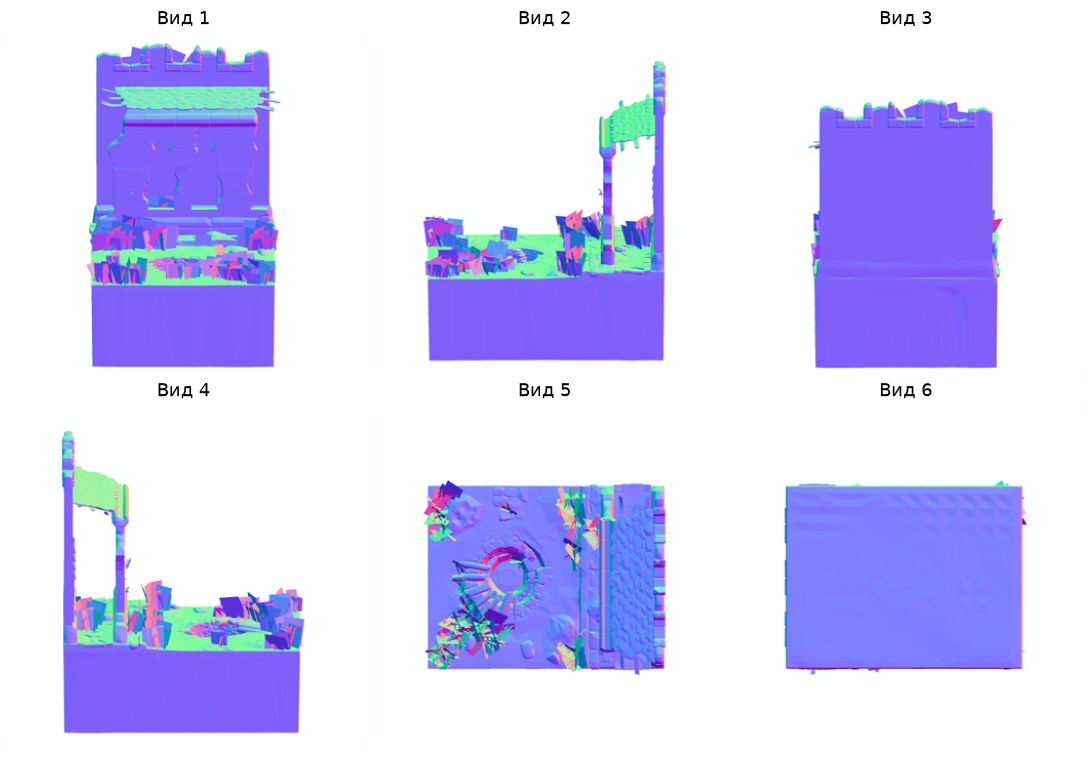

In [7]:
example_id = train_ids[0]

views = image_views(
    DATA / 'train' / f'{example_id}.png', CONFIG
)

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for index, ax in enumerate(axes.flat):
    rgb = views[index].permute(1, 2, 0).numpy() * np.array(CONFIG['image_std']) + np.array(CONFIG['image_mean'])
    ax.imshow(rgb.clip(0, 1))
    ax.set_title(f'Вид {index + 1}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Общий цикл обучения и метрики

Каждая модель выдаёт десять logits. Обучаем с `BCEWithLogitsLoss`. Weighted AP оценивает ранжирование без порогов и использовалась для выбора эпох в исследованиях. Конкурсный балл рассчитывается после бинаризации: `10 × F1(quality) + 10 × weighted F1(defects)`.

Для текущего прогона число эпох уже зафиксировано. Во время повторного обучения внутренние validation-метрики 3D-модели можно видеть в журнале, но они не меняют выбранную длительность обучения. Накопление градиентов позволяет обучать patch-голову с микробатчем 1 и эффективным батчем 16.

In [8]:
def predict_model(
        model,
        dataset,
        batch_size=16
    ):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    model.eval()
    probabilities, loss_sum = [], 0.0
    with torch.inference_mode():
        for features, targets in loader:
            logits = model(features.to(DEVICE))
            loss = nn.functional.binary_cross_entropy_with_logits(logits, targets[:, :10].to(DEVICE))
            loss_sum += loss.item() * len(features)
            probabilities.append(logits.sigmoid().cpu().numpy())
    return np.concatenate(probabilities), loss_sum / len(dataset)


def train_one_epoch(
        model,
        loader,
        optimizer,
        effective_batch,
        scaler,
        use_amp=False
    ):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    accumulation = effective_batch // loader.batch_size
    total_loss = 0.0
    for step, (features, targets) in enumerate(loader):
        features, targets = features.to(DEVICE), targets[:, :10].to(DEVICE)
        window_start = (step // accumulation) * effective_batch
        window_size = min(effective_batch, len(loader.dataset) - window_start)
        context = torch.autocast('cuda', dtype=torch.float16) if use_amp else nullcontext()
        with context:
            logits = model(features)
            loss = nn.functional.binary_cross_entropy_with_logits(logits.float(), targets.float())
        scaler.scale(loss * len(features) / window_size).backward()
        total_loss += loss.item() * len(features)
        if (step + 1) % accumulation == 0 or step + 1 == len(loader):
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0, error_if_nonfinite=True)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
    return total_loss / len(loader.dataset)


def fit_fixed(
        factory,
        dataset,
        config,
        output_name,
        validation_dataset=None
    ):
    seed_everything(config['seed'])
    model = factory().to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )

    microbatch = config.get('microbatch', config.get('batch_size', 16))
    effective_batch = config.get('effective_batch', microbatch)
    use_amp = DEVICE.type == 'cuda' and config.get('amp', False)

    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    loader = DataLoader(
        dataset,
        batch_size=microbatch,
        shuffle=True,
        num_workers=0,
        generator=torch.Generator().manual_seed(config['seed'])
    )

    history = []
    RUN_DIR.mkdir(parents=True, exist_ok=True)

    for epoch in range(1, config['epochs'] + 1):
        started = perf_counter()
        loss = train_one_epoch(
            model,
            loader,
            optimizer,
            effective_batch,
            scaler,
            use_amp
        )
        row = {'epoch': epoch, 'train_loss': loss}
        if validation_dataset is not None:
            probabilities, valid_loss = predict_model(model, validation_dataset, microbatch)
            row.update(scores(validation_dataset.targets, probabilities))
            row['valid_loss'] = valid_loss
        row['seconds'] = perf_counter() - started
        history.append(row)
        pd.DataFrame(history).to_csv(RUN_DIR / f'{output_name}_history.csv', index=False)
        torch.save({key: value.detach().cpu() for key, value in model.state_dict().items()}, RUN_DIR / f'{output_name}.pt')
        print(f'''{output_name}: эпоха {epoch}/{config['epochs']}
Train loss: {loss:.5f}; время: {row['seconds']:.1f} с
''', flush=True)
    (RUN_DIR / f'{output_name}_config.json').write_text(json.dumps(config, indent=2))
    return model.eval(), pd.DataFrame(history)

## 6. Визуальный baseline

По шести CLS-векторам считаем mean и max, объединяем их в вектор длины 768 и передаём в MLP. Фиксируем hidden dim 256, dropout 0.2, AdamW с LR 0.001 и weight decay 0.01. Обучение длится 5 эпох на всех 5970 объектах train.

In [9]:
class CachedMultiViewHead(nn.Module):
    def __init__(self, hidden_dim=256, dropout=0.2):
        super().__init__()
        self.fusion = nn.Sequential(
            nn.LayerNorm(768),
            nn.Linear(768, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.defect_head = nn.Linear(hidden_dim, 10)

    def forward(self, features):
        pooled = torch.cat([features.mean(1), features.amax(1)], dim=-1)
        return self.defect_head(self.fusion(pooled))

class GlobalDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.as_tensor(features, dtype=torch.float32)
        self.targets = torch.as_tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.targets[index]

In [10]:
baseline_config = COMPARISONS['baseline']
baseline = CachedMultiViewHead(
    baseline_config['hidden_dim'],
    baseline_config['dropout']
).to(DEVICE)

if RUN_TRAINING:
    all_features = global_features(ROOT, train_ids + valid_ids, DATA / 'train', ASSETS, CONFIG, DEVICE)
    baseline_train = GlobalDataset(all_features[:len(train_ids)], train_y)
    baseline_valid = GlobalDataset(all_features[len(train_ids):], valid_y)
    baseline, baseline_history = fit_fixed(
        lambda: CachedMultiViewHead(baseline_config['hidden_dim'], baseline_config['dropout']),
        baseline_train, baseline_config, 'baseline')
    baseline_p, _ = predict_model(baseline, baseline_valid)
else:
    baseline.load_state_dict(torch.load(ASSETS / 'baseline.pt', map_location='cpu', weights_only=True))
    baseline_history = pd.read_csv(ROOT / 'reports/baseline_history.csv')
    with np.load(ASSETS / 'baseline_predictions.npz') as saved:
        rows = {item: i for i, item in enumerate(saved['item_ids'].astype(str))}
        baseline_p = saved['probabilities'][[rows[item] for item in valid_ids]]

display(baseline_history.round(5))

,epoch,train_loss,seconds
0,1,0.21050,1.11524
1,2,0.17843,1.01197
2,3,0.16816,0.86280
3,4,0.15712,0.79773
4,5,0.14819,0.75346


## 7. Геометрия: точки поверхности и нормали

Грани выбираются пропорционально площади. Внутри треугольника точка выбирается равномерно через барицентрические координаты. Нормаль берём от исходной грани, без сглаживания. Нормализация сохраняет пропорции объекта: центр bounding box переносим в ноль, длину наибольшей оси делаем равной единице.

Для каждого меша сохраняем 32768 точек, затем детерминированно выбираем 8192. Вход имеет форму `[8192, 6]`: XYZ и нормаль. Реализация с обработкой граней частями находится в `src/mesh_quality/geometry.py`.

In [11]:
import plotly.graph_objects as go

geometry_example = SurfaceDataset(
    ROOT,
    DATA / 'train',
    [example_id],
    labels.loc[[example_id], target_columns].to_numpy()
)

point_features, _ = geometry_example[0]
xyz = point_features[:, :3].numpy()

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=xyz[:, 0],
            y=xyz[:, 1],
            z=xyz[:, 2],
            mode='markers',
            marker=dict(
                size=2,
                color=xyz[:, 2],
                colorscale='Viridis',
                opacity=0.85,
                colorbar=dict(title='Z')
            ),
            hovertemplate=(
                'X: %{x:.4f}<br>'
                'Y: %{y:.4f}<br>'
                'Z: %{z:.4f}'
                '<extra></extra>'
            )
        )
    ]
)

fig.update_layout(
    title=f'{len(xyz):,} точек поверхности<br>{example_id}',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'
    ),
    template='plotly_white',
    height=650,
    margin=dict(l=0, r=0, b=0, t=80)
)

fig.show()

Две ступени группируют соседние точки: 512 центров, затем 128; по 32 соседа на обеих ступенях. Локальная MLP использует относительные координаты и признаки соседей. Max pooling даёт признак группы, затем mean и max по объекту поступают в классификатор.

В исследовании 64 соседа увеличили покрытие точек, но не дали устойчивого улучшения после калибровки. Здесь оставляем конфигурацию с 32 соседями и 18 эпохами. Исторический checkpoint обучен на внутренних 4775 объектах; это явно отличается от 5970 у визуальных моделей.

In [12]:
@torch.no_grad()
def chunked_knn(
    xyz,
    queries,
    k,
    chunk_size=64,
):
    if not 1 <= k <= xyz.shape[1] or chunk_size < 1:
        raise ValueError("Некорректные k или chunk_size.")

    source_norm = xyz.square().sum(dim=-1).unsqueeze(1)

    source_transposed = xyz.transpose(1, 2)

    index_blocks = []

    for start in range(0, queries.shape[1], chunk_size):
        query_block = queries[
            :,
            start : start + chunk_size,
        ]

        # Квадраты евклидовых расстояний:
        # ||q - x||² = ||q||² + ||x||² - 2(q · x).
        distances = (
            query_block.square().sum(
                dim=-1,
                keepdim=True,
            )
            + source_norm
            - 2
            * torch.bmm(
                query_block,
                source_transposed,
            )
        )

        distances.clamp_min_(0)

        indices = distances.topk(
            k,
            dim=-1,
            largest=False,
            sorted=False,
        ).indices

        index_blocks.append(indices)

    return torch.cat(index_blocks, dim=1)

class LocalGroupingBlock(nn.Module):
    def __init__(
        self,
        input_dim,
        num_centers,
        neighbors,
        hidden_dim,
        output_dim,
        chunk_size=64,
    ):
        super().__init__()

        self.num_centers = num_centers
        self.neighbors = neighbors
        self.chunk_size = chunk_size

        self.local_mlp = nn.Sequential(
            nn.Linear(input_dim + 3, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, output_dim),
            nn.LayerNorm(output_dim),
            nn.GELU(),
        )

    def forward(self, xyz, features):
        if xyz.shape[1] < self.num_centers:
            raise ValueError("Недостаточно точек для выбранного числа центров.")

        centers = xyz[:, : self.num_centers]

        indices = chunked_knn(
            xyz=xyz,
            queries=centers,
            k=self.neighbors,
            chunk_size=self.chunk_size,
        )

        batch_indices = torch.arange(
            xyz.shape[0],
            device=xyz.device,
        )[:, None, None]

        neighbor_xyz = xyz[
            batch_indices,
            indices,
        ]

        neighbor_features = features[
            batch_indices,
            indices,
        ]

        relative_xyz = neighbor_xyz - centers.unsqueeze(2)

        local_inputs = torch.cat(
            [
                relative_xyz,
                neighbor_features,
            ],
            dim=-1,
        )

        local_features = self.local_mlp(local_inputs).amax(dim=2)

        return centers, local_features

class LocalGeometryClassifier(nn.Module):
    def __init__(
        self,
        num_defects,
        centers=(512, 128),
        neighbors=(32, 32),
        chunk_size=64,
        dropout=0.2,
    ):
        super().__init__()

        self.stage1 = LocalGroupingBlock(
            input_dim=3,
            num_centers=centers[0],
            neighbors=neighbors[0],
            hidden_dim=64,
            output_dim=96,
            chunk_size=chunk_size,
        )

        self.stage2 = LocalGroupingBlock(
            input_dim=96,
            num_centers=centers[1],
            neighbors=neighbors[1],
            hidden_dim=128,
            output_dim=192,
            chunk_size=chunk_size,
        )

        self.global_projection = nn.Sequential(
            nn.Linear(192 + 3, 256),
            nn.LayerNorm(256),
            nn.GELU(),
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(512),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_defects),
        )

    def forward(self, inputs):
        if inputs.ndim != 3 or inputs.shape[-1] != 6:
            raise ValueError("Ожидается [batch, points, 6].")

        xyz = inputs[..., :3]
        normals = inputs[..., 3:]

        xyz1, features1 = self.stage1(xyz, normals)

        xyz2, features2 = self.stage2(xyz1, features1)

        object_tokens = self.global_projection(
            torch.cat(
                [xyz2, features2],
                dim=-1,
            )
        )

        pooled = torch.cat(
            [
                object_tokens.mean(dim=1),
                object_tokens.amax(dim=1),
            ],
            dim=-1,
        )

        return self.classifier(pooled)

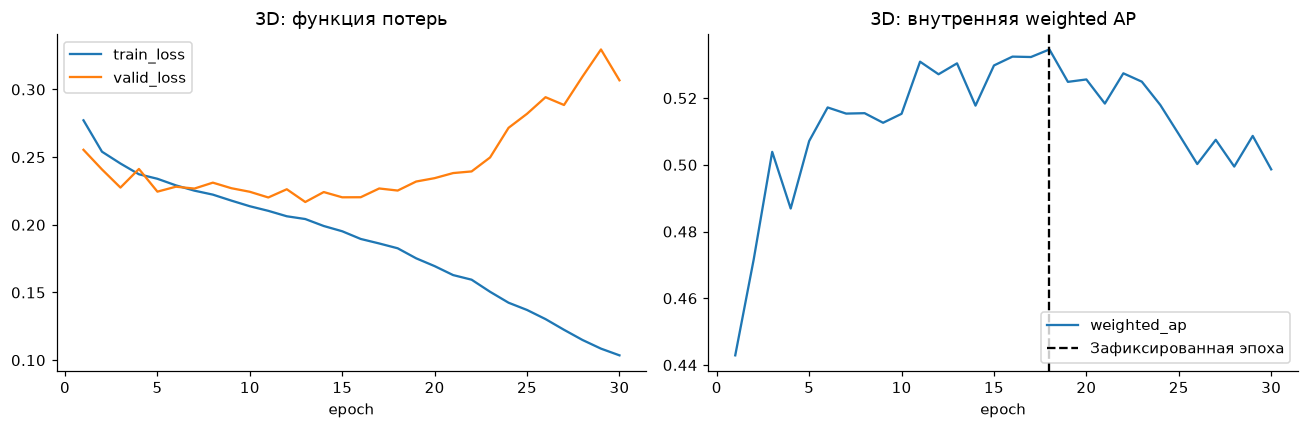

In [ ]:
geometry_config = COMPARISONS['geometry']
geometry = LocalGeometryClassifier(**COMPARISONS['geometry_model']).to(DEVICE)
if RUN_TRAINING:
    geo_train = SurfaceDataset(
        ROOT,
        DATA / 'train',
        inner_train_ids,
        labels.loc[inner_train_ids, target_columns].to_numpy()
    )
    geo_inner = SurfaceDataset(
        ROOT,
        DATA / 'train',
        inner_valid_ids,
        labels.loc[inner_valid_ids, target_columns].to_numpy()
    )

    geometry, geometry_history = fit_fixed(
        lambda: LocalGeometryClassifier(**COMPARISONS['geometry_model']),
        geo_train, geometry_config, 'geometry', geo_inner)
    geo_valid = SurfaceDataset(ROOT, DATA / 'train', valid_ids, valid_y)
    geometry_p, _ = predict_model(geometry, geo_valid, geometry_config['batch_size'])
else:
    geometry.load_state_dict(torch.load(
        ASSETS / 'geometry.pt',
        map_location='cpu',
        weights_only=True
    ))
    
    geometry_history = pd.read_csv(ROOT / 'reports/geometry_history.csv')
    with np.load(ASSETS / 'geometry_predictions.npz') as saved:
        rows = {item: i for i, item in enumerate(saved['item_ids'].astype(str))}
        geometry_p = saved['probabilities'][[rows[item] for item in valid_ids]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
geometry_history.plot(x='epoch', y=['train_loss', 'valid_loss'], ax=axes[0])
geometry_history.plot(x='epoch', y='weighted_ap', ax=axes[1])
axes[0].set_title('3D: функция потерь')
axes[1].axvline(geometry_config['epochs'], ls='--', color='black', label='Зафиксированная эпоха')
axes[1].set_title('3D: внутренняя weighted AP')
axes[1].legend()
plt.tight_layout()
plt.show()

В режиме сохранённых результатов график показывает весь исследовательский запуск до 30-й эпохи и выбранную 18-ю. При повторном обучении строится новый журнал из 18 эпох. Потери обучения продолжают снижаться после максимума validation AP: дальнейшее обучение этой конфигурации не улучшало ранжирование.

## 8. Финальная модель: patch_only336

Из каждого ракурса получаем сетку 24×24 токенов DINOv2. Общая проекция уменьшает размерность 384 до 128. Каждый из десяти классов обучает своё распределение attention по 3456 токенам всех видов. Взвешенные признаки поступают в MLP и десять выходных классификаторов.

В сохранённой голове есть нулевая глобальная ветвь длины 768. Она участвует в LayerNorm; сохраняем её, чтобы вычисления совпадали с отправленным решением. Encoder заморожен. Обучаем только голову, по 6 эпох для seed 42, 17 и 123, затем усредняем вероятности.

In [14]:
class PatchClassifier(nn.Module):
    def __init__(self, config):
        super().__init__()
        dim = config["feature_dim"]
        projected = config["projection_dim"]
        classes = len(config["defect_columns"])
        self.dim = dim
        self.classes = classes
        self.projection = nn.Sequential(
            nn.LayerNorm(dim), nn.Linear(dim, projected), nn.GELU()
        )
        self.attention = nn.Linear(projected, classes)
        # The zero global branch preserves the submitted checkpoint's LayerNorm
        # and weight layout. Removing it would change the trained function.
        self.fusion = nn.Sequential(
            nn.LayerNorm(2 * dim + projected),
            nn.Linear(2 * dim + projected, config["hidden_dim"]),
            nn.GELU(),
            nn.Dropout(config["dropout"]),
        )
        self.defect_head = nn.Linear(config["hidden_dim"], classes)

    def forward(self, patches, return_attention=False):
        tokens = self.projection(patches.flatten(1, 2))
        attention = self.attention(tokens).softmax(dim=1)
        local = torch.einsum("btc,btd->bcd", attention, tokens)
        zeros = torch.zeros(
            (patches.shape[0], self.classes, 2 * self.dim),
            device=patches.device,
            dtype=patches.dtype,
        )
        representation = self.fusion(torch.cat([zeros, local], dim=-1))
        logits = (representation * self.defect_head.weight[None]).sum(
            -1
        ) + self.defect_head.bias
        return (logits, attention) if return_attention else logits

class PatchDataset(Dataset):
    def __init__(self, store, ids, targets=None):
        self.store, self.ids, self.targets = store, list(ids), targets

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, index):
        row = self.store.rows[self.ids[index]]
        if not self.store.ready[row]:
            raise RuntimeError(
                "Extract features before starting training or inference."
            )
        patches = torch.from_numpy(np.array(self.store.patches[row], dtype=np.float32))
        return (
            patches
            if self.targets is None
            else (patches, torch.as_tensor(self.targets[index], dtype=torch.float32))
        )

,model,input,train_objects,epochs,hidden_dim,dropout
0,baseline,224,5970,5,256,0.200000
1,geometry,8192 точки,4775,18,256,0.200000
2,patch_only336 × 3 seed,336,5970,6,256,0.434835


,epoch,weighted_ap
name,,
patch_only336,6,0.7322
patch_only336_consistent,6,0.7316
global224,12,0.6953


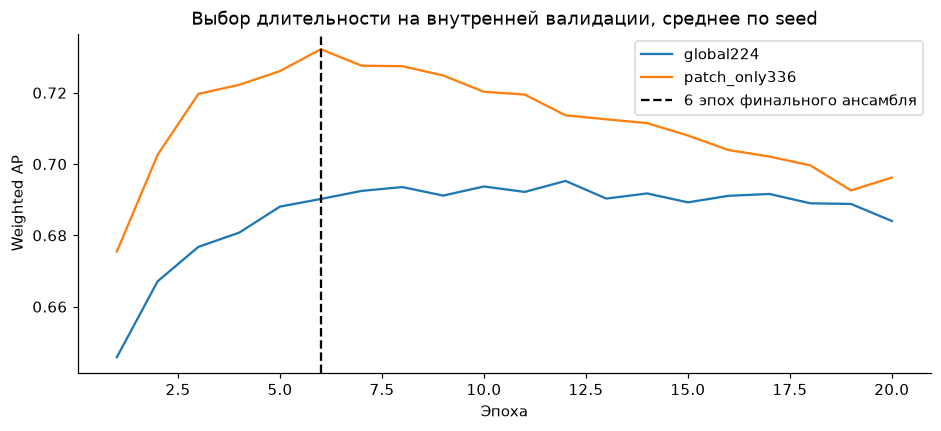

In [15]:
display(pd.DataFrame([
    ['baseline', 224, 5970, 5, 256, 0.2],
    ['geometry', '8192 точки', 4775, 18, 256, 0.2],
    ['patch_only336 × 3 seed', 336, 5970, 6, CONFIG['hidden_dim'], CONFIG['dropout']],
], columns=['model', 'input', 'train_objects', 'epochs', 'hidden_dim', 'dropout']))

display(pd.read_csv(ROOT / 'reports/seed_mean_choices.csv').set_index('name').round(4))
selection = pd.read_csv(ROOT / 'reports/selection_curves.csv')
fig, ax = plt.subplots(figsize=(10, 4))
for name, group in selection.groupby('name'):
    curve = group.groupby('epoch').weighted_ap.mean()
    ax.plot(curve.index, curve, label=name)
ax.axvline(CONFIG['epochs'], color='black', ls='--', label='6 эпох финального ансамбля')
ax.set(xlabel='Эпоха', ylabel='Weighted AP', title='Выбор длительности на внутренней валидации, среднее по seed')
ax.legend()
plt.show()

Кэш patch-признаков всех размеченных объектов занимает около 22.2 GiB. Он хранится на диске в float16; голова получает float32. Локальный готовый кэш переиспользуется, при переносе на Colab признаки извлекаются из PNG. На CUDA обучение patch-головы использует AMP; MPS использует float32. Из-за различий вычислений повторное обучение на разных устройствах может дать другие веса и ответы.

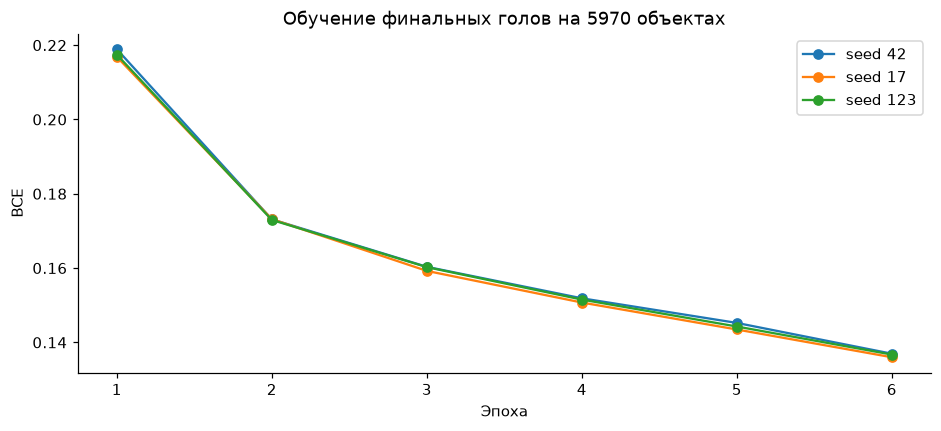

In [ ]:
patch_histories = {}
if RUN_TRAINING:
    training_store = feature_store(
        ROOT,
        splits.item_id.tolist(),
        CONFIG,
        'labeled'
    )

    training_store.ensure(train_ids + valid_ids, DATA / 'train', ASSETS, DEVICE)
    patch_train = PatchDataset(training_store, train_ids, train_y)
    for seed in CONFIG['seeds']:
        settings = dict(CONFIG, seed=seed, amp=True)
        model, history = fit_fixed(
            lambda: PatchClassifier(CONFIG),
            patch_train,
            settings,
            f'head_seed{seed}'
        )
        patch_histories[seed] = history
        del model
    ACTIVE_ASSETS = RUN_DIR
    patch_p = predict_ensemble(training_store, valid_ids, ACTIVE_ASSETS, CONFIG, DEVICE)
else:
    with np.load(ASSETS / 'predictions.npz') as saved:
        rows = {item: i for i, item in enumerate(saved['item_ids'].astype(str))}
        patch_p = saved['probabilities'][[rows[item] for item in valid_ids]]
    for seed in CONFIG['seeds']:
        patch_histories[seed] = pd.read_csv(ROOT / f'reports/train_seed{seed}.csv')

fig, ax = plt.subplots(figsize=(10, 4))
for seed, history in patch_histories.items():
    ax.plot(history.epoch, history.train_loss, marker='o', label=f'seed {seed}')
ax.set(xlabel='Эпоха', ylabel='BCE', title='Обучение финальных голов на 5970 объектах')
ax.legend()
plt.show()

## 9. Калибровка порогов и сравнение моделей

У каждого дефекта свой порог. Координатный поиск меняет один порог за раз и оценивает всю конкурсную метрику, включая `quality`. Поэтому оптимальные пороги зависят друг от друга. Делаем до пяти проходов по классам, останавливаемся, если улучшений нет. Ни метки check, ни тестовые ответы в подбор не входят.

Для сохранённого ансамбля используем зафиксированные пороги отправленного файла. Для заново обученных моделей подбираем их на той же calibration. Таблицы сравнения всегда относятся к одинаковым объектам.

In [17]:
def tune_thresholds(y, p, passes=5):
    # Vectorized F1 updates: AP is never recomputed inside threshold search.
    y = np.asarray(y)
    p = np.asarray(p)
    truth = y[:, :10].astype(bool)
    support = truth.sum(0).astype(float)
    weights = support / support.sum()
    grid = np.unique(np.r_[np.geomspace(0.001, 0.1, 25), np.arange(1, 100) / 100, 0.5])
    t = np.full(10, 0.5)
    pred = p >= t
    history = []

    def defect_f1(pred):
        tp = (pred & truth).sum(0)
        return np.divide(
            2 * tp,
            support + pred.sum(0),
            out=np.zeros(10),
            where=(support + pred.sum(0)) > 0,
        )

    best = scores(y, p, t, False)["f1_final"]
    for pass_id in range(passes):
        changed = False
        for j in range(10):
            candidates = p[:, j, None] >= grid[None, :]
            other = np.delete(pred, j, axis=1).any(1)
            q = ~(other[:, None] | candidates)
            qy = y[:, 10].astype(bool)
            tpq = (q & qy[:, None]).sum(0)
            denq = q.sum(0) + qy.sum()
            qf = np.divide(2 * tpq, denq, out=np.zeros(len(grid)), where=denq > 0)
            tp = (candidates & truth[:, j, None]).sum(0)
            den = support[j] + candidates.sum(0)
            cf = np.divide(2 * tp, den, out=np.zeros(len(grid)), where=den > 0)
            f = defect_f1(pred)
            base = float(np.dot(weights, f) - weights[j] * f[j])
            values = 10 * (qf + base + weights[j] * cf)
            ix = int(values.argmax())
            if values[ix] > best + 1e-12:
                old = t[j]
                t[j] = grid[ix]
                pred[:, j] = candidates[:, ix]
                best = float(values[ix])
                changed = True
                history.append(
                    {
                        "pass": pass_id + 1,
                        "defect": defects[j],
                        "old": old,
                        "threshold": t[j],
                        "f1_final": best,
                    }
                )
        if not changed:
            break
    return t, pd.DataFrame(history)

In [18]:
probabilities = {'baseline': baseline_p, 'geometry': geometry_p, 'patch_ensemble': patch_p}
thresholds = {}
calibration_rows = []
for name, p in probabilities.items():
    if not RUN_TRAINING:
        filename = {'baseline': 'baseline_predictions.npz', 'geometry': 'geometry_predictions.npz', 'patch_ensemble': 'predictions.npz'}[name]
        with np.load(ASSETS / filename) as saved:
            thresholds[name] = saved['thresholds'].copy()
    else:
        thresholds[name], _ = tune_thresholds(valid_y[calibration], p[calibration])
    for part, mask in [('calibration', calibration), ('check', check)]:
        for variant, threshold in [('0.5', 0.5), ('tuned', thresholds[name])]:
            calibration_rows.append({'model': name, 'split': part, 'variant': variant, **scores(valid_y[mask], p[mask], threshold)})
comparison = pd.DataFrame(calibration_rows).set_index(['split', 'model', 'variant'])
display(comparison[['f1_quality', 'f1_defects_weighted', 'f1_final', 'weighted_ap']].round(4))
display(pd.DataFrame(thresholds, index=defects).rename_axis('defect').round(4))
ACTIVE_CONFIG['thresholds'] = thresholds['patch_ensemble'].tolist()
comparison.to_csv(OUTPUT / 'model_comparison.csv')
if RUN_TRAINING:
    (RUN_DIR / 'final_config.json').write_text(json.dumps(ACTIVE_CONFIG, indent=2))
    (RUN_DIR / 'thresholds.json').write_text(json.dumps({key: value.tolist() for key, value in thresholds.items()}, indent=2))
    for name, p in probabilities.items():
        np.savez_compressed(RUN_DIR / f'{name}_predictions.npz', item_ids=np.asarray(valid_ids),
                            targets=valid_y, probabilities=p, thresholds=thresholds[name],
                            calibration_mask=calibration, check_mask=check)


f1_quality  f1_defects_weighted  f1_final  \
split       model          variant                                              
calibration baseline       0.5          0.5029               0.5889   10.9184   
                           tuned        0.6510               0.6400   12.9092   
check       baseline       0.5          0.4806               0.5765   10.5711   
                           tuned        0.5595               0.6124   11.7190   
calibration geometry       0.5          0.3723               0.4271    7.9943   
                           tuned        0.4489               0.5049    9.5378   
check       geometry       0.5          0.3767               0.4169    7.9361   
                           tuned        0.4082               0.4794    8.8761   
calibration patch_ensemble 0.5          0.6178               0.6560   12.7379   
                           tuned        0.7474               0.6962   14.4361   
check       patch_ensemble 0.5          0.5921               0.6352   12.2729   
                           tuned        0.6456               0.6762   13.2177   

                                    weighted_ap  
split       model          variant               
calibration baseline       0.5           0.6835  
                           tuned         0.6835  
check       baseline       0.5           0.6693  
                           tuned         0.6693  
calibration geometry       0.5           0.5248  
                           tuned         0.5248  
check       geometry       0.5           0.5174  
                           tuned         0.5174  
calibration patch_ensemble 0.5           0.7460  
                           tuned         0.7460  
check       patch_ensemble 0.5           0.7285  
                           tuned         0.7285

,baseline,geometry,patch_ensemble
defect,,,
abstract,0.2000,0.2000,0.3900
artifacts,0.1100,0.0900,0.0681
intersection,0.0562,0.0300,0.1200
lowpoly,0.5300,0.4700,0.4600
noisy,0.5300,0.1700,0.5400
open,0.0900,0.0825,0.1800
partial,0.0383,0.3600,0.3300
scale,0.0100,0.0700,0.0900
set,0.2700,0.2600,0.1800


## 10. Разбор качества по классам

Все следующие таблицы строятся по check. Сначала сравниваем precision, recall и F1 до и после подбора порогов. AP и доля положительных объектов помогают увидеть классы, для которых ранжирование ещё слабое. Увеличение recall само по себе не гарантирует рост конкурсного балла: ложная метка дефекта отклоняет хороший объект.

,precision,recall,f1,support,predicted_positive,TP,FP,FN,AP,positive_share,threshold
defect,,,,,,,,,,,
intersection,0.0000,0.0000,0.0000,18,8,0,8,18,0.0818,0.0120,0.1200
open,0.3176,0.2967,0.3068,91,85,27,58,64,0.2763,0.0607,0.1800
scale,0.2917,0.4118,0.3415,17,24,7,17,10,0.2562,0.0113,0.0900
artifacts,0.2842,0.7222,0.4078,72,183,52,131,20,0.3363,0.0481,0.0681
partial,0.5926,0.5161,0.5517,62,54,32,22,30,0.5930,0.0414,0.3300
set,0.4936,0.7436,0.5934,156,235,116,119,40,0.7023,0.1041,0.1800
lowpoly,0.7273,0.5622,0.6341,185,143,104,39,81,0.7079,0.1235,0.4600
simple,0.6405,0.7360,0.6850,322,370,237,133,85,0.7433,0.2150,0.3100
noisy,0.8490,0.8090,0.8285,424,404,343,61,81,0.9115,0.2830,0.5400


,threshold_before,precision_before,recall_before,f1_before,threshold_after,precision_after,recall_after,f1_after,delta_f1,defect_score_gain
defect,,,,,,,,,,
artifacts,0.5,0.3333,0.0139,0.0267,0.0681,0.2842,0.7222,0.4078,0.3812,0.1775
open,0.5,0.8333,0.0549,0.1031,0.1800,0.3176,0.2967,0.3068,0.2037,0.1199
scale,0.5,0.0000,0.0000,0.0000,0.0900,0.2917,0.4118,0.3415,0.3415,0.0375
simple,0.5,0.7510,0.6087,0.6724,0.3100,0.6405,0.7360,0.6850,0.0126,0.0262
partial,0.5,0.6667,0.3871,0.4898,0.3300,0.5926,0.5161,0.5517,0.0619,0.0248
lowpoly,0.5,0.7462,0.5243,0.6159,0.4600,0.7273,0.5622,0.6341,0.0183,0.0219
abstract,0.5,0.8098,0.8342,0.8218,0.3900,0.7928,0.8844,0.8361,0.0143,0.0184
intersection,0.5,0.0000,0.0000,0.0000,0.1200,0.0000,0.0000,0.0000,0.0000,0.0000
set,0.5,0.6774,0.5385,0.6000,0.1800,0.4936,0.7436,0.5934,-0.0066,-0.0067


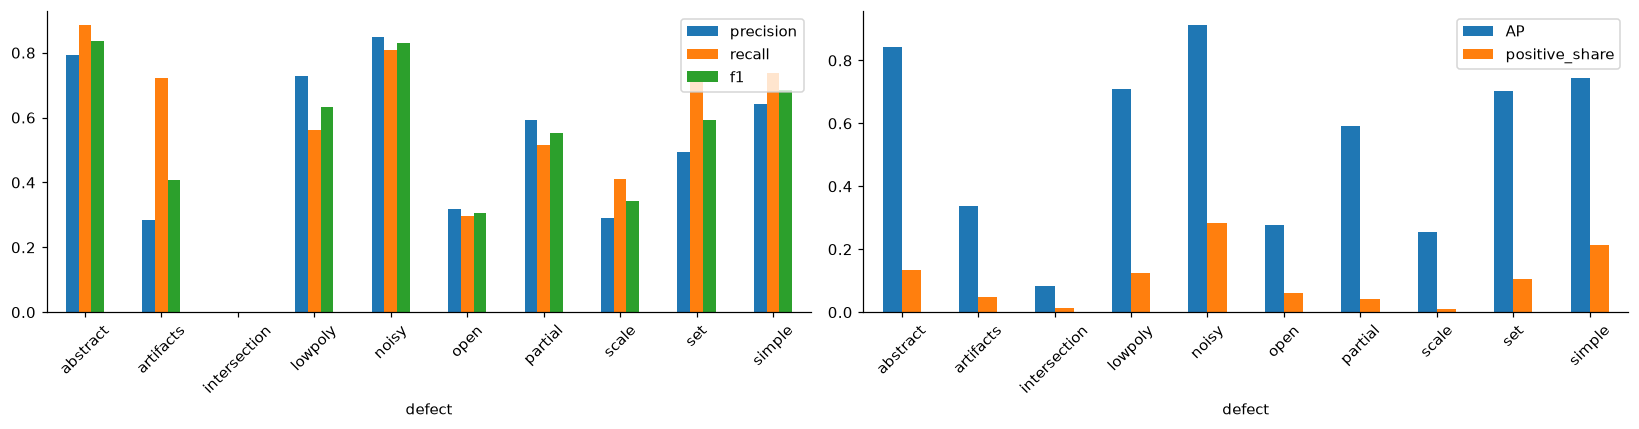

In [19]:
def per_class_report(y, p, threshold):
    pred = p >= threshold
    precision, recall, f1, support = precision_recall_fscore_support(y[:, :10], pred, average=None, zero_division=0)
    truth = y[:, :10].astype(bool)
    return pd.DataFrame({
        'precision': precision, 'recall': recall, 'f1': f1,
        'support': support, 'predicted_positive': pred.sum(0),
        'TP': (truth & pred).sum(0), 'FP': (~truth & pred).sum(0), 'FN': (truth & ~pred).sum(0),
        'AP': average_precision_score(truth, p, average=None), 'positive_share': truth.mean(0),
        'threshold': np.broadcast_to(threshold, (10,)),
    }, index=pd.Index(defects, name='defect'))

before = per_class_report(valid_y[check], patch_p[check], 0.5)
after = per_class_report(valid_y[check], patch_p[check], thresholds['patch_ensemble'])
display(after.sort_values('f1').round(4))
changes = before[['threshold', 'precision', 'recall', 'f1']].join(after[['threshold', 'precision', 'recall', 'f1']], lsuffix='_before', rsuffix='_after')
changes['delta_f1'] = after.f1 - before.f1
changes['defect_score_gain'] = 10 * changes.delta_f1 * after.support / after.support.sum()
display(changes.sort_values('defect_score_gain', ascending=False).round(4))
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
after[['precision', 'recall', 'f1']].plot.bar(ax=axes[0])
after[['AP', 'positive_share']].plot.bar(ax=axes[1])
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

count     p10  median     p90     max
defect       group                                             
abstract     Дефекта нет   1299  0.0002  0.0027  0.0695  0.9442
             Дефект есть    199  0.3514  0.8286  0.9301  0.9484
artifacts    Дефекта нет   1426  0.0005  0.0062  0.0586  0.5229
             Дефект есть     72  0.0137  0.1171  0.3799  0.5701
intersection Дефекта нет   1480  0.0001  0.0019  0.0222  0.3976
             Дефект есть     18  0.0033  0.0379  0.0824  0.0848
lowpoly      Дефекта нет   1313  0.0010  0.0116  0.1796  0.8917
             Дефект есть    185  0.0739  0.5265  0.9110  0.9326
noisy        Дефекта нет   1074  0.0014  0.0117  0.2627  0.9915
             Дефект есть    424  0.1843  0.9205  0.9911  0.9977
open         Дефекта нет   1407  0.0018  0.0153  0.1116  0.5546
             Дефект есть     91  0.0170  0.0781  0.3764  0.6954
partial      Дефекта нет   1436  0.0001  0.0015  0.0359  0.7959
             Дефект есть     62  0.0139  0.3557  0.7754  0.8802
scale        Дефекта нет   1481  0.0001  0.0006  0.0136  0.2539
             Дефект есть     17  0.0051  0.0788  0.1788  0.3890
set          Дефекта нет   1342  0.0004  0.0082  0.1518  0.8662
             Дефект есть    156  0.0536  0.5914  0.8996  0.9438
simple       Дефекта нет   1176  0.0006  0.0107  0.3393  0.9822
             Дефект есть    322  0.1177  0.6337  0.9358  0.9867

,bad_as_bad,bad_as_good,good_as_bad,good_as_good
model,,,,
baseline,1153,116,95,134
geometry,1112,157,130,99
patch_ensemble,1177,92,76,153


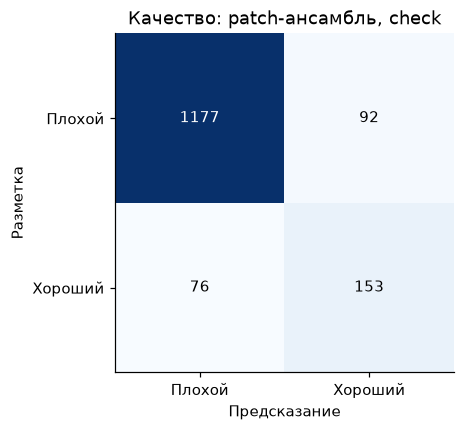

In [ ]:
distribution_rows = []
for index, defect in enumerate(defects):
    for value, title in [(0, 'Дефекта нет'), (1, 'Дефект есть')]:
        values = patch_p[check & (valid_y[:, index] == value), index]
        if len(values):
            distribution_rows.append(
                {
                    'defect': defect,
                    'group': title,
                    'count': len(values),
                    'p10': np.quantile(values, .1),
                    'median': np.median(values),
                    'p90': np.quantile(values, .9), 
                    'max': values.max()
                }
            )

display(pd.DataFrame(distribution_rows).set_index(['defect', 'group']).round(4))

quality_rows = []
for name, p in probabilities.items():
    good = ~(p[check] >= thresholds[name]).any(1)
    tn, fp, fn, tp = confusion_matrix(valid_y[check, 10], good, labels=[0, 1]).ravel()
    quality_rows.append(
        {
            'model': name,
            'bad_as_bad': tn,
            'bad_as_good': fp,
            'good_as_bad': fn,
            'good_as_good': tp
        }
    )

display(pd.DataFrame(quality_rows).set_index('model'))
cm = confusion_matrix(valid_y[check, 10], ~(patch_p[check] >= thresholds['patch_ensemble']).any(1), labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap='Blues')
for (i, j), value in np.ndenumerate(cm):
    ax.text(j, i, str(value), ha='center', va='center', color='white' if value > cm.max()/2 else 'black')
ax.set(
    xticks=[0, 1],
    yticks=[0, 1],
    xticklabels=['Плохой', 'Хороший'],
    yticklabels=['Плохой', 'Хороший'],
    xlabel='Предсказание',
    ylabel='Разметка',
    title='Качество: patch-ансамбль, check'
)
plt.show()

## 11. Тестовый инференс и submission

Извлекаем признаки тестовых изображений, загружаем три головы и усредняем их вероятности. Порядок строк берём из `test.csv`. В режиме воспроизведения сверяем новый файл с отправленным CSV. При повторном обучении используем новые веса и пороги; результат такого запуска не получает автоматически прежний конкурсный балл.

In [21]:
test_store = feature_store(ROOT, test_ids, CONFIG, 'test')
test_store.ensure(test_ids, DATA / 'test', ASSETS, DEVICE)
test_probabilities = predict_ensemble(test_store, test_ids, ACTIVE_ASSETS, ACTIVE_CONFIG, DEVICE)
submission_path = (RUN_DIR if RUN_TRAINING else OUTPUT) / 'submission.csv'
submission = save_submission(test_ids, test_probabilities, ACTIVE_CONFIG, submission_path)
np.savez_compressed(OUTPUT / 'test_probabilities.npz', item_ids=np.asarray(test_ids), probabilities=test_probabilities)

reference = pd.read_csv(ROOT / 'reports/submission_reference.csv', dtype={'item_id': str})
if submission.item_id.tolist() != reference.item_id.tolist():
    raise ValueError('Порядок тестовых ID отличается от отправленного CSV.')
differences = int((submission[defects + ['quality']].to_numpy() != reference[defects + ['quality']].to_numpy()).sum())
print(f'''Создан файл: {submission_path.relative_to(ROOT)}
Объектов: {len(submission)}
Отличий от отправленных бинарных ответов: {differences}
SHA-256: {sha256(submission_path)}
''')
if differences and not RUN_TRAINING:
    raise RuntimeError('Предсказания отличаются от отправленных. Проверьте версии среды и веса перед отправкой.')
display(submission.head())

Three-seed ensemble:   0%|          | 0/669 [00:00<?, ?it/s]

Создан файл: outputs/final/submission.csv
Объектов: 669
Отличий от отправленных бинарных ответов: 0
SHA-256: 6a2628bf66fb9ce60727e1ca4ed40b9962e227db13b2d5d706c26dca8e18906f



,item_id,abstract,artifacts,intersection,lowpoly,noisy,open,partial,scale,set,simple,quality
0,002f4a73-0a18-40a8-b2bf-5f5e63743850,1,0,0,0,0,0,0,0,0,0,0
1,0054f4fe-ae32-48b1-bbc4-8e978cd20038,0,0,0,0,0,0,0,0,0,1,0
2,0148ab6e-5b6a-44fd-8710-9df11206676e,0,0,0,0,1,0,0,0,0,0,0
3,02fea41f-ad32-4277-a3d3-cb4390f931c7,1,0,0,1,0,0,0,0,0,0,0
4,03bcb9bd-df4a-4354-9113-e7111f6b373d,0,0,0,0,0,0,0,0,0,1,0


## 12. Что влияет на предсказание

Для одного объекта показаны три способа анализа. Attention выделяет токены с большим весом для выбранного дефекта. Gradient × token показывает чувствительность средней вероятности ансамбля к признакам. Изменение вероятности Δp в заголовке вида измеряется после замены его признаков средним остальных видов.

Эти карты помогают изучать решение модели, но не являются разметкой дефекта и не доказывают физическую причину. Замена признаков может создавать сочетания, которых не было в обучении. Для ошибок используем check с известными метками; тестовый пример показан без утверждения, верен ли его ответ.

Для теста выбран пример с вероятностью, ближайшей к порогу. Шкала attention общая для шести видов; gradient × token показан с отсечением крайних 1% абсолютных значений, чтобы были видны слабые изменения.

Правильно найденный дефект


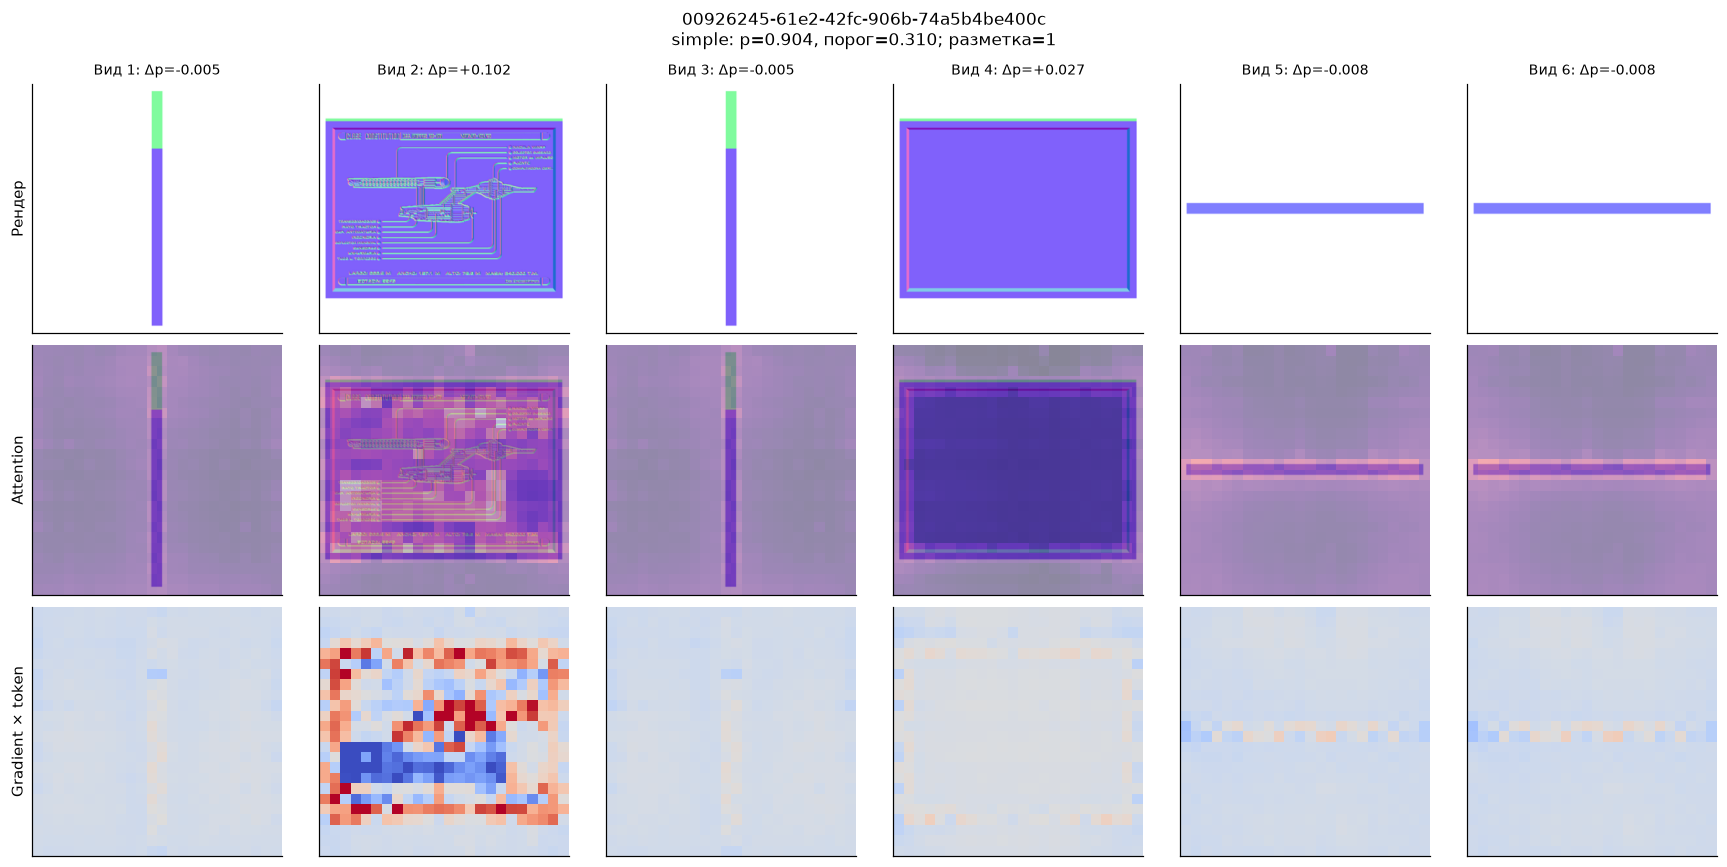

Хороший объект ошибочно отклонён


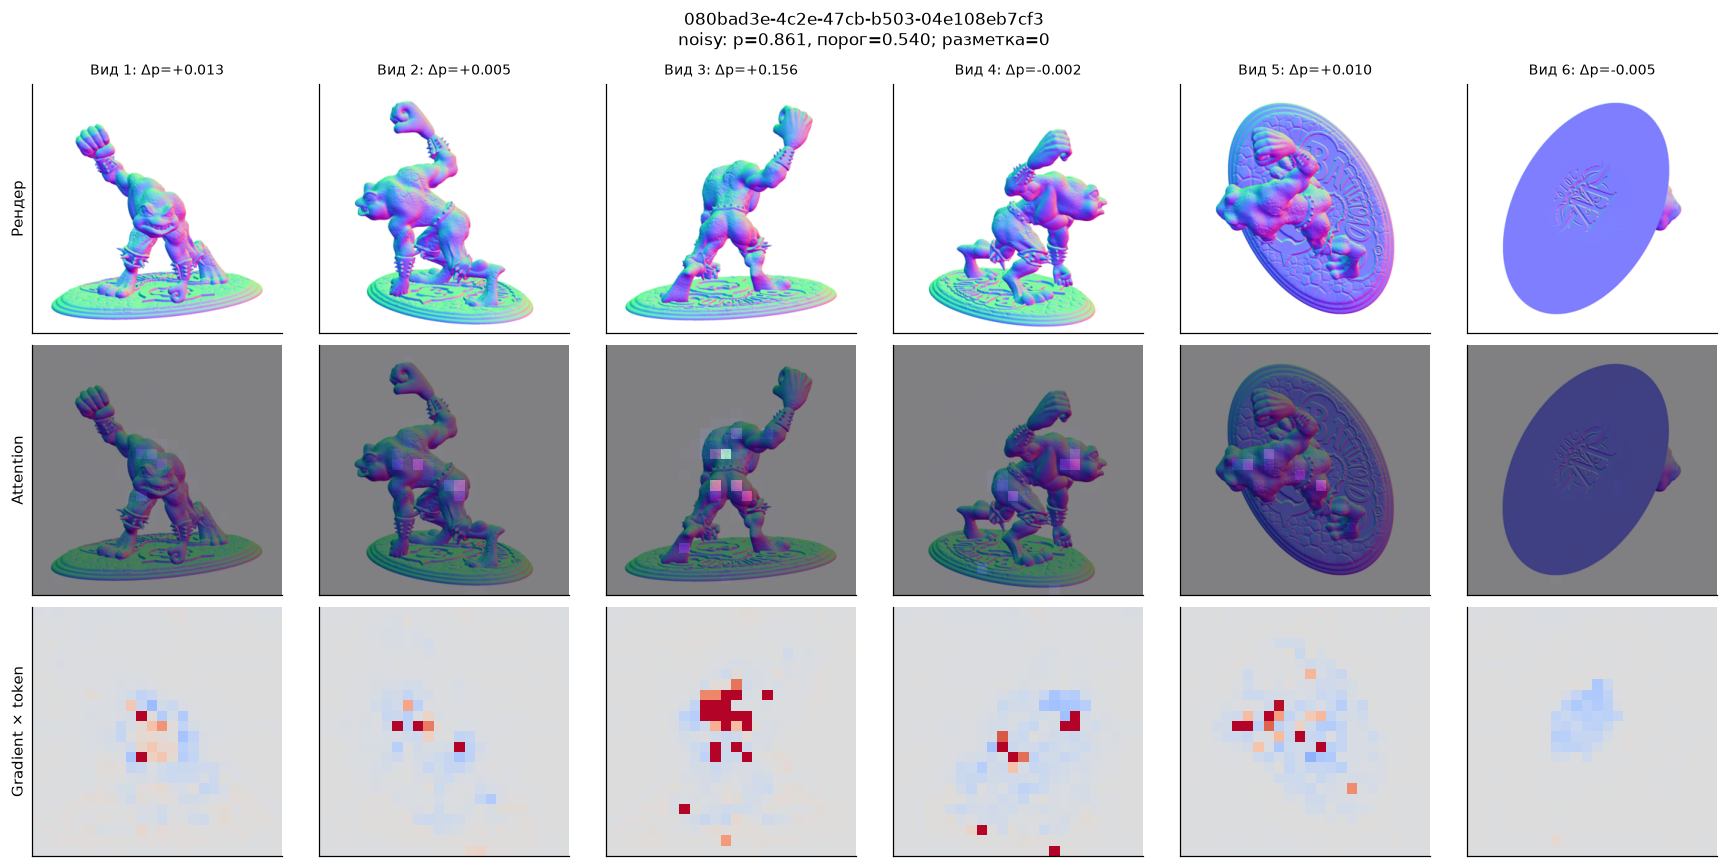

Плохой объект ошибочно принят


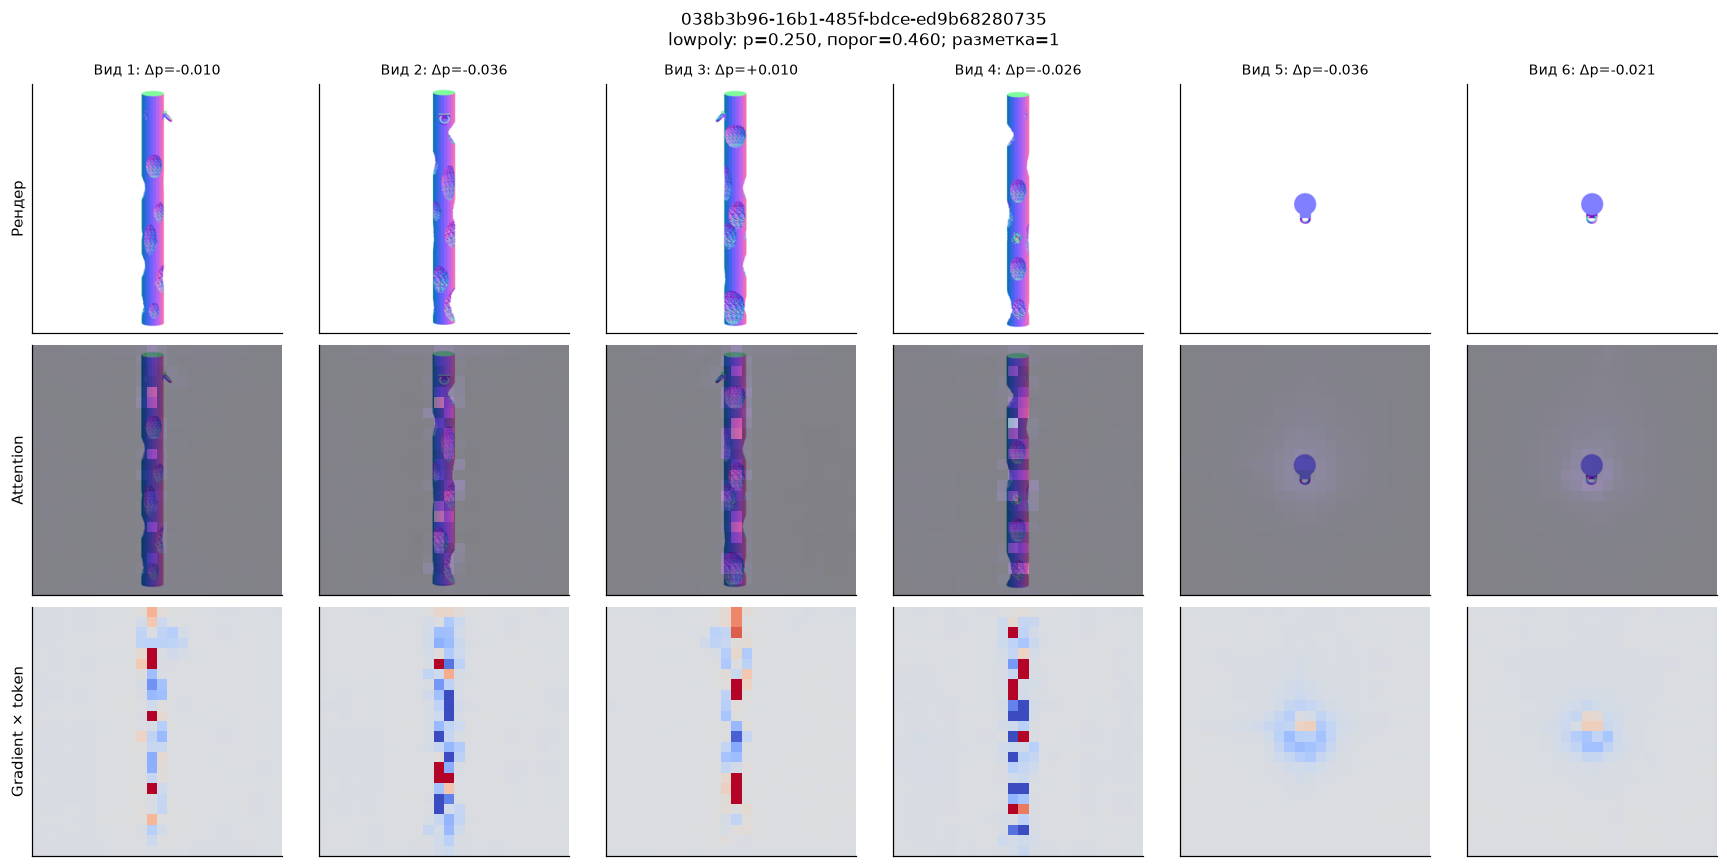

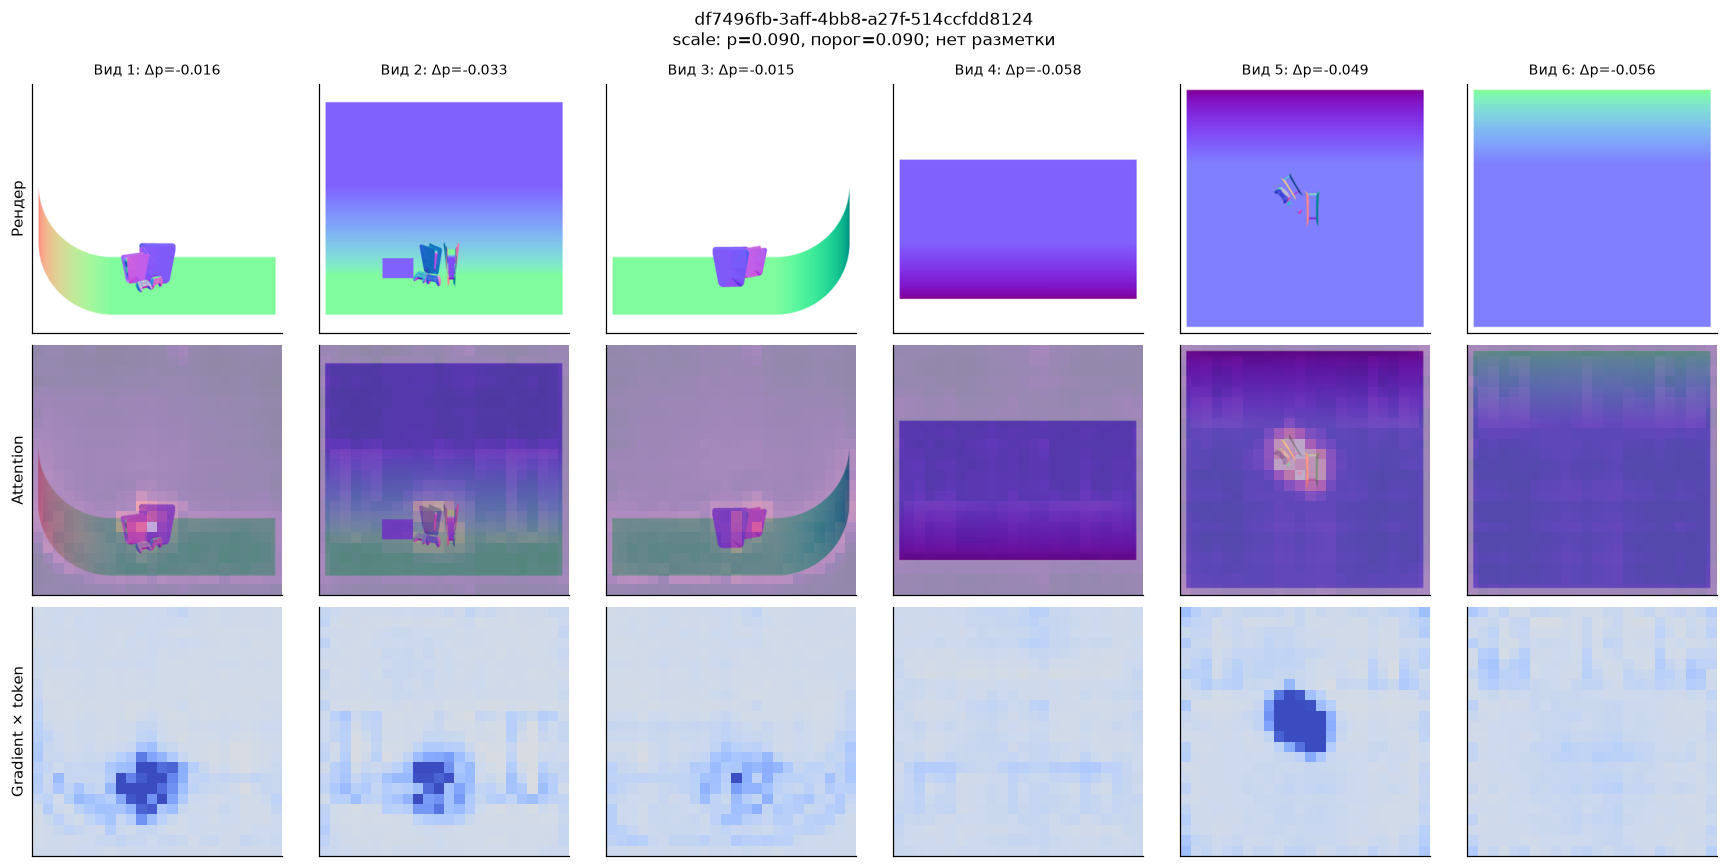

In [22]:
if RUN_EXPLANATIONS:
    val_ids = np.asarray(valid_ids)
    val_y = valid_y
    val_p = patch_p
    predicted_defects = val_p >= ACTIVE_CONFIG['thresholds']
    predicted_good = ~predicted_defects.any(axis=1)
    cases = {
        'Правильно найденный дефект': check & (val_y[:, 10] == 0) & ~predicted_good & ((predicted_defects & (val_y[:, :10] == 1)).any(1)),
        'Хороший объект ошибочно отклонён': check & (val_y[:, 10] == 1) & ~predicted_good,
        'Плохой объект ошибочно принят': check & (val_y[:, 10] == 0) & predicted_good,
    }
    chosen = [int(np.flatnonzero(mask)[0]) for mask in cases.values() if mask.any()]
    explanation_store = feature_store(ROOT, splits.item_id.tolist(), CONFIG, 'labeled')
    explanation_store.ensure(val_ids[chosen], DATA / 'train', ASSETS, DEVICE)
    for title, mask in cases.items():
        if not mask.any():
            continue
        i = int(np.flatnonzero(mask)[0])
        j = int(np.argmax(val_p[i] - ACTIVE_CONFIG['thresholds'])) if val_y[i, 10] == 1 else int(np.flatnonzero((val_y[i, :10] == 1) & predicted_defects[i])[0]) if ((val_y[i, :10] == 1) & predicted_defects[i]).any() else int(np.flatnonzero(val_y[i, :10])[0])
        print(title)
        figure = explain_object(explanation_store, val_ids[i], DATA / 'train', ACTIVE_ASSETS, ACTIVE_CONFIG, DEVICE, defects[j], val_y[i, j])
        figure.savefig(OUTPUT / f'explanation_{val_ids[i]}.png', dpi=110, bbox_inches='tight')
        plt.show()
        plt.close(figure)

    test_index, defect_index = np.unravel_index(
        np.abs(test_probabilities - ACTIVE_CONFIG['thresholds']).argmin(), test_probabilities.shape
    )
    figure = explain_object(test_store, test_ids[test_index], DATA / 'test', ACTIVE_ASSETS, ACTIVE_CONFIG, DEVICE, defects[defect_index])
    figure.savefig(OUTPUT / 'explanation_test.png', dpi=110, bbox_inches='tight')
    plt.show()
    plt.close(figure)

## 13. Выводы и ограничения

Численные результаты этого раздела относятся к сохранённому отправленному ансамблю. После повторного обучения актуальные значения показаны в таблицах выше.

Переход от глобальных embeddings к локальным patch-признакам дал основное улучшение. Ансамбль трёх seed получил 14.2215 на платформе; прежняя модель с глобальными признаками получала 12.8114. На check у финального ансамбля F1 качества равен 0.6456, weighted F1 дефектов — 0.6762.

На check ошибочно отклонены 76 хороших объектов и пропущены 92 плохих. `Open`, `intersection` и `scale` остаются сложными классами. Изображения не всегда позволяют уверенно судить о внутренней геометрии; региональной разметки для проверки карт объяснений нет.

Следующий содержательный эксперимент — завершить fine-tuning patch-модели и проверить его на тех же правилах оценки.

### Материалы

- [DINOv2](https://github.com/facebookresearch/dinov2): предобученный визуальный encoder.
- [timm](https://github.com/huggingface/pytorch-image-models): используемая реализация ViT.
- [Attention-based Deep Multiple Instance Learning](https://arxiv.org/abs/1802.04712): идея обучаемого взвешивания локальных признаков. Здесь используется собственная лёгкая голова для десяти классов.
- [scikit-learn: F1](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html): расчёт конкурсной метрики.

Конфигурация находится в `configs/final.json`, группы и разбиение — в `configs/splits.csv`, реальные журналы и метрики — в `reports/`.

Baseline и 3D оставлены как самостоятельные обучаемые сравнения. В финальном submission используется только patch-ансамбль. Результаты выше пересчитываются из выбранных весов или сохранённых validation-предсказаний; кривые выбора эпох явно отделены от окончательного обучения.